EN ESTE NOTEBOOK:

- Coger datos limpios (datos.csv), y de esos coger las pacientes que no tienen missings en:
    - hta_pregest (pre - MODELO A)
    - hta_cronica (post - MODELO A)
    - ant_infarto_ictus (post - MODELO A)
    - ta_sistolica (outcome1 - MODELO B)
    - ta_diastolica (outcome1 - MODELO B)
    - ldl (outcome 2 - MODELO B)
    - colesterol_total (outcome 2 - MODELO B)
    - hdl (outcome 2 - MODELO B)
    - trigliceridos (outcome 2 - MODELO B)
    - medicacion_hipolipemiante (outcome 2 - MODELO B)

A partir de `datos.csv` se crean 3 datasets independientes, uno por análisis:

| Análisis | Variables | Dataset |
|---|---|---|
| **Modelo A** (*pregnancy-only*) | `hta_pregest` (pre) → `hta_cronica` o `ant_infarto_ictus` (post) | `df_A` |
| **Modelo B · outcome 1** (TA) | `ta_sistolica`, `ta_diastolica` | `df_B1` |
| **Modelo B · outcome 2** (lípidos) | `ldl`, `colesterol_total`, `hdl`, `trigliceridos`, `medicacion_hipolipemiante` | `df_B2` |

- **Modelo A**: comparación pre→post y test de significación.
- **Modelo B**: para cada paciente, marcar si está por encima / dentro / por debajo de los
  valores recomendados.

## 0. Carga de datos + puente a `datos_preprocesados.csv`

`medicacion_hipolipemiante` no está en `datos.csv` (se eliminó por >25% missings) pero la necesita
el **outcome 2 (lípidos)**; se recupera de `datos_preprocesados.csv`. Codificación (verificada en
diccionario + datos): **No/Sí → 0/1**, `NaN` = no toma → flag "toma" = `valor == 1`.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest
pd.set_option('display.width', 120)

df = pd.read_csv('datos.csv', low_memory=False)
df['id'] = df['id'].astype(float)

# medicacion_hipolipemiante no está en datos.csv (eliminada por >25% missings); se recupera
# de datos_preprocesados.csv. Es campo No/Sí (0/1): NaN = no toma. Flag "toma" = valor == 1.
prep = pd.read_csv('datos_preprocesados.csv', low_memory=False)
prep['id'] = prep['id'].astype(float)
df = df.merge(prep[['id', 'medicacion_hipolipemiante']], on='id', how='left')
df['medicacion_hipolipemiante_flag'] = (pd.to_numeric(df['medicacion_hipolipemiante'], errors='coerce') == 1).astype(int)

print('Cohorte:', df.shape)
print('Toman hipolipemiante (consta):', df['medicacion_hipolipemiante_flag'].sum(), '/', len(df))

Cohorte: (459, 346)
Toman hipolipemiante (consta): 2 / 459


/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_3091/2714304329.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['medicacion_hipolipemiante_flag'] = (pd.to_numeric(df['medicacion_hipolipemiante'], errors='coerce') == 1).astype(int)


## 1. MODELO A — *pregnancy-only* (pre → post)

- **PRE**: `hta_pregest` — HTA pregestacional (0 No / 1 Sí).
- **POST** (evento CV actual, *outcome compuesto binario*):
  - `hta_cronica` — HTA crónica actual de la paciente (0/1), y
  - `ant_infarto_ictus` — antecedente de infarto o ictus (0/1).
  - **post = 1** si *cualquiera* de las dos es 1; **post = 0** si ambas son 0.
- Ambas son variables directas de la paciente del bloque "características basales actuales"
  (en `datos.csv`, sin missings en las 459).


In [2]:
pre = pd.to_numeric(df['hta_pregest'], errors='coerce')
# POST = evento CV actual: HTA crónica O antecedente de infarto/ictus
hta_cr = pd.to_numeric(df['hta_cronica'], errors='coerce')
inf_ict = pd.to_numeric(df['ant_infarto_ictus'], errors='coerce')
post = ((hta_cr == 1) | (inf_ict == 1)).astype('Int64')
post[hta_cr.isna() & inf_ict.isna()] = pd.NA   # no evaluable si faltan ambas

df_A = df.assign(hta_pre=pre, evento_cv_post=post).dropna(subset=['hta_pre', 'evento_cv_post']).copy()
df_A['hta_pre'] = df_A['hta_pre'].astype(int)
df_A['evento_cv_post'] = df_A['evento_cv_post'].astype(int)
print('df_A:', len(df_A), 'pacientes\n')

tabla_A = pd.crosstab(df_A['hta_pre'], df_A['evento_cv_post'],
                      rownames=['HTA pregestacional (pre)'],
                      colnames=['Evento CV actual: HTA crónica o infarto/ictus (post)'])
print(tabla_A, '\n')

b = int(((df_A['hta_pre'] == 0) & (df_A['evento_cv_post'] == 1)).sum())   # desarrollan
c_ = int(((df_A['hta_pre'] == 1) & (df_A['evento_cv_post'] == 0)).sum())  # revierten
persist = int(((df_A['hta_pre'] == 1) & (df_A['evento_cv_post'] == 1)).sum())
print(f'0 pre -> 1 post (desarrollan evento CV): {b}')
print(f'1 pre -> 0 post (revierten):             {c_}')
print(f'1 pre -> 1 post (persistente):           {persist}')

if b + c_ > 0:
    p = binomtest(min(b, c_), b + c_, 0.5).pvalue
    print(f'McNemar (exacto): p = {p:.4f}  ({"significativo" if p < 0.05 else "no significativo"} al 5%)')

df_A: 459 pacientes

Evento CV actual: HTA crónica o infarto/ictus (post)    0   1
HTA pregestacional (pre)                                     
0                                                     406  29
1                                                       3  21 

0 pre -> 1 post (desarrollan evento CV): 29
1 pre -> 0 post (revierten):             3
1 pre -> 1 post (persistente):           21
McNemar (exacto): p = 0.0000  (significativo al 5%)


## 2. MODELO B — Outcome 1: Tensión arterial

Dataset `df_B1`: pacientes sin missing en `ta_sistolica` y `ta_diastolica`.
Cada paciente se clasifica como **por debajo / dentro / por encima** de los valores recomendados.

Cortes (parametrizables en `CORTES_TA`):
- **Por debajo** (hipotensión): TAS < 90 o TAD < 60.
- **Dentro** (normal): 90-139 / 60-89.
- **Por encima** (HTA): TAS ≥ 140 o TAD ≥ 90.

In [3]:
CORTES_TA = {'tas_baja': 90, 'tad_baja': 60, 'tas_alta': 140, 'tad_alta': 90}

df_B1 = df.dropna(subset=['ta_sistolica', 'ta_diastolica']).copy()

def clasifica_ta(row):
    tas, tad = row['ta_sistolica'], row['ta_diastolica']
    if tas >= CORTES_TA['tas_alta'] or tad >= CORTES_TA['tad_alta']:
        return 'Por encima (HTA)'
    if tas < CORTES_TA['tas_baja'] or tad < CORTES_TA['tad_baja']:
        return 'Por debajo (hipotensión)'
    return 'Dentro (normal)'

df_B1['clasificacion_ta'] = df_B1.apply(clasifica_ta, axis=1)
print('df_B1:', len(df_B1), 'pacientes\n')
res_B1 = df_B1['clasificacion_ta'].value_counts().rename('n').to_frame()
res_B1['%'] = (res_B1['n'] / len(df_B1) * 100).round(1)
print(res_B1)

df_B1: 455 pacientes

                            n     %
clasificacion_ta                   
Dentro (normal)           384  84.4
Por encima (HTA)           47  10.3
Por debajo (hipotensión)   24   5.3


## 3. MODELO B — Outcome 2: Lípidos

Dataset `df_B2`: pacientes sin missing en `ldl`, `colesterol_total`, `hdl`, `trigliceridos`
(`medicacion_hipolipemiante`: flag `== 1`).

Se marca cada parámetro fuera de rango (`CORTES_LIPIDOS`):
- **LDL elevado** ≥ 130 · **Colesterol total elevado** ≥ 200 · **HDL bajo** < 50 (mujer) ·
  **Triglicéridos elevados** ≥ 150 mg/dL · **Tratamiento hipolipemiante** existente.

In [4]:
CORTES_LIPIDOS = {'ldl': 130, 'colesterol_total': 200, 'hdl_min': 50, 'trigliceridos': 150}

df_B2 = df.dropna(subset=['ldl', 'colesterol_total', 'hdl', 'trigliceridos']).copy()
df_B2['ldl_elevado']        = df_B2['ldl'] >= CORTES_LIPIDOS['ldl']
df_B2['colesterol_elevado'] = df_B2['colesterol_total'] >= CORTES_LIPIDOS['colesterol_total']
df_B2['hdl_bajo']           = df_B2['hdl'] < CORTES_LIPIDOS['hdl_min']
df_B2['tg_elevado']         = df_B2['trigliceridos'] >= CORTES_LIPIDOS['trigliceridos']
df_B2['toma_hipolipemiante'] = df_B2['medicacion_hipolipemiante_flag'] == 1

flags = ['ldl_elevado', 'colesterol_elevado', 'hdl_bajo', 'tg_elevado', 'toma_hipolipemiante']
df_B2['dislipemia'] = df_B2[flags].any(axis=1)

print('df_B2:', len(df_B2), 'pacientes\n')
res_B2 = pd.DataFrame({'n': [int(df_B2[f].sum()) for f in flags + ['dislipemia']]},
                      index=flags + ['dislipemia'])
res_B2['%'] = (res_B2['n'] / len(df_B2) * 100).round(1)
print(res_B2)

df_B2: 315 pacientes

                       n     %
ldl_elevado           79  25.1
colesterol_elevado    93  29.5
hdl_bajo              84  26.7
tg_elevado            23   7.3
toma_hipolipemiante    1   0.3
dislipemia           160  50.8


# Análisis variable 'resultado_iberliferisk_score_hasta_los_75_anos'

In [6]:
df2 = pd.read_csv('datos_preprocesados.csv')
df2['resultado_iberliferisk_score_hasta_los_75_anos'].isnull().sum()

np.int64(198)

In [7]:
df2.shape

(608, 433)

In [8]:
df2['resultado_iberliferisk_score_hasta_los_75_anos'].min()

np.float64(0.03)

In [9]:
df2['resultado_iberliferisk_score_hasta_los_75_anos'].max()

np.float64(18.56)

In [10]:
df2['resultado_iberliferisk_score_hasta_los_75_anos'].mean()

np.float64(0.5451707317073171)

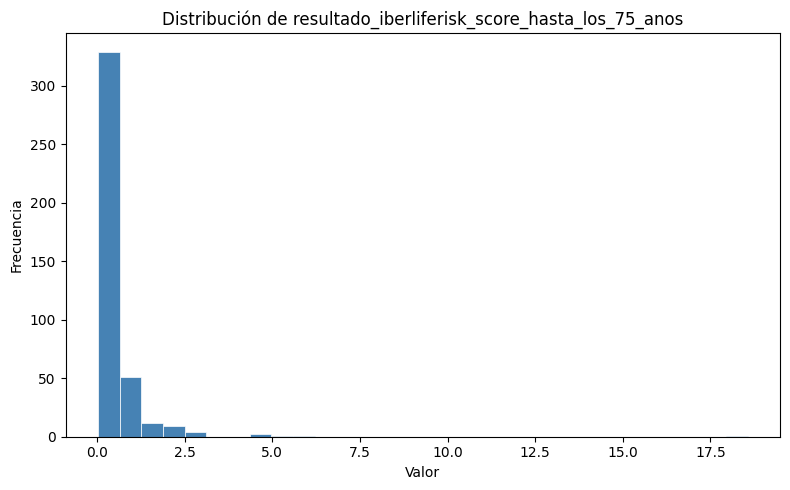

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df2['resultado_iberliferisk_score_hasta_los_75_anos'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_title('Distribución de resultado_iberliferisk_score_hasta_los_75_anos')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [12]:
df2['resultado_iberliferisk_score_hasta_los_75_anos'].nlargest(10)

291    18.56
81      6.17
312     5.32
383     4.84
106     4.44
121     3.11
281     3.02
97      2.94
228     2.59
178     2.45
Name: resultado_iberliferisk_score_hasta_los_75_anos, dtype: float64